In [11]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
from sklearn.preprocessing import StandardScaler
sns.set_style("whitegrid")

In [13]:
os.chdir(r"C:\Users\priya\OneDrive\Desktop\salesAnalysis")
os.getcwd()

'C:\\Users\\priya\\OneDrive\\Desktop\\salesAnalysis'

In [14]:
master = pd.read_csv("master_orders.csv")
customers = pd.read_csv("customer_model_data.csv")
master.head()

,customer_unique_id,customer_id,customer_city,customer_state,order_id,order_status,purchase_time,delivered_time,estimated_time,delivery_delay,product_id,seller_id,price,freight_value,category_name,weight_grams,payment_amount,installments,review_score
0,dc83fe8f72fb4388f079a2f9b586240c,9c2f403519bcb363683a7179f0f94bd4,itaquaquecetuba,SP,a41753c6a1d8accb89732e36243432d7,delivered,2017-05-12 10:51:43,2017-05-19 14:13:02,2017-06-05 00:00:00,-17,e3e020af31d4d89d2602272b315c3f6e,94144541854e298c2d976cb893b81343,30,16,beleza_saude,75.0,46.0,3.0,NaN
1,b289291bcfd0b339685b14bf220db3ad,7ffae0a2b02796d8e66fdbf0fa6e08b5,sao jose dos campos,SP,eba18dfa91e31cf748f9f52b779f9ae8,delivered,2017-11-14 08:13:32,2017-11-20 22:42:38,2017-12-01 00:00:00,-11,154e7e31ebfa092203795c972e5804a6,cc419e0650a3c5ba77189a1882b7556a,24,8,beleza_saude,100.0,32.0,1.0,NaN
2,f0903f4311560f0f99dca752df6dfa67,669b06cabc9d39c1bcc52e6889e1318d,boa esperanca do sul,SP,13b825fdc28948500cfc7a03eb975fbc,delivered,2018-02-13 11:05:56,2018-02-21 20:09:22,2018-03-12 00:00:00,-19,e9f4a2b16f44a27e454037659cceb20f,b4ffb71f0cb1b1c3d63fad021ecf93e1,31,12,automotivo,200.0,43.0,1.0,NaN
3,5e5a11984e21d9a4d1d09efbfcdf6031,ae9eb176fc71a9dd239b71a82b3d6c88,lorena,SP,7afb8d408d72272d7353f90ec6870d5e,delivered,2018-03-08 16:36:14,2018-03-26 22:11:47,2018-03-26 00:00:00,0,70b1659e9e180610c8a5fd5753c85b80,11bfa66332777660bd0640ee84d47006,13,13,perfumaria,100.0,52.0,2.0,NaN
4,714d0049eb8668f261ea08a8284a9f31,5a23a92261328e087c062a7c265b7862,sao miguel,RN,8e0aba4e9cd80e71b2cec14e22df868b,delivered,2017-11-15 12:08:23,2017-12-05 20:23:37,2017-12-15 00:00:00,-10,a1766f2d27b4e90a0d78d8e115295399,17e34d8224d27a541263c4c64b11a56b,102,35,perfumaria,450.0,137.0,4.0,NaN


In [15]:
customers.head()

,customer_unique_id,total_orders,total_revenue,avg_review,avg_delay,avg_installments
0,0000366f3b9a7992bf8c76cfdf3221e2,1,130.0,NaN,-5.0,8.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,19.0,NaN,-5.0,1.0
2,0000f46a3911fa3c0805444483337064,1,69.0,NaN,-2.0,8.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,26.0,NaN,-12.0,4.0
4,0004aac84e0df4da2b147fca70cf8255,1,180.0,NaN,-8.0,6.0


Does Delivery Speed Affect Customer Reviews?
                delivery_delay  review_score
delivery_delay             1.0           NaN
review_score               NaN           NaN


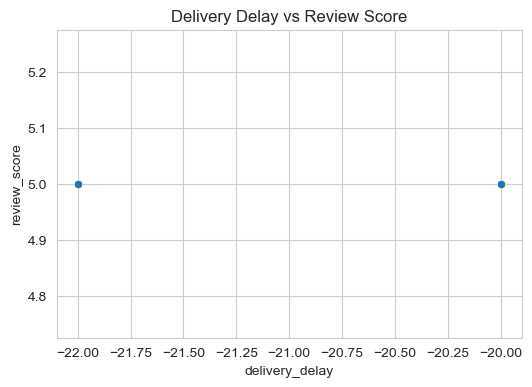

In [29]:
print("Does Delivery Speed Affect Customer Reviews?")
correlation = master[['delivery_delay','review_score']].corr()
print(correlation)

plt.figure(figsize=(6,4))
sns.scatterplot(data=master,
                x='delivery_delay',
                y='review_score')
plt.title("Delivery Delay vs Review Score")
plt.show()

Which Cities Generate High Revenue but Low Satisfaction?
             customer_city  price  review_score
329              sao paulo  17227           NaN
284         rio de janeiro   7470           NaN
186                jundiai   4371           NaN
108               curitiba   3584           NaN
42          belo horizonte   3039           NaN
52                brasilia   2886           NaN
289               salvador   2721           NaN
271           porto alegre   1841           NaN
134                goiania   1720           NaN
307  sao bernardo do campo   1407           NaN
70                campinas   1400           NaN
295      santa fe de goias   1299           NaN
121          fatima do sul   1139           NaN
313            sao goncalo   1031           NaN
56               buerarema    989           NaN
249            pato branco    979           NaN
250                  patos    957           NaN
308              sao borja    950           NaN
346        taboao da serra    9

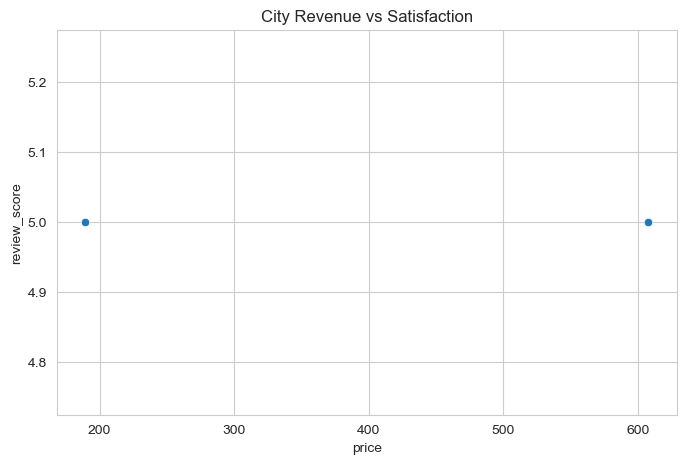

In [33]:
print("Which Cities Generate High Revenue but Low Satisfaction?")
city = master.groupby('customer_city').agg({
    'price':'sum',
    'review_score':'mean'
}).reset_index()
top_revenue = city.sort_values('price', ascending=False).head(20)
print(top_revenue)

plt.figure(figsize=(8,5))
sns.scatterplot(data=city,
                x='price',
                y='review_score')
plt.title("City Revenue vs Satisfaction")
plt.show()

Which Sellers Cause Most Delays?
seller_id
cac4c8e7b1ca6252d8f20b2fc1a2e4af    161.0
8759e7aedd644f487315e5860962f162     40.0
04aba03279157f6d4e0fe8ccaf21963c     22.0
31344c16881c08a8a72c6d2eb29918c1     18.0
c37b2059d4f90d4feead554e5246565e     14.0
e24fc9fcd865784fb25705606fe3dfe7     14.0
9c57bc60cfad5ee62d35d3f1ce4593a1     14.0
729f06993dac8e860d4f02d7088ca48a     13.0
834f8533b2ecb6598dd004ff3de7203a     12.0
7bac63f6603d382cc8d0832eb6c100a8     10.0
Name: delivery_delay, dtype: float64


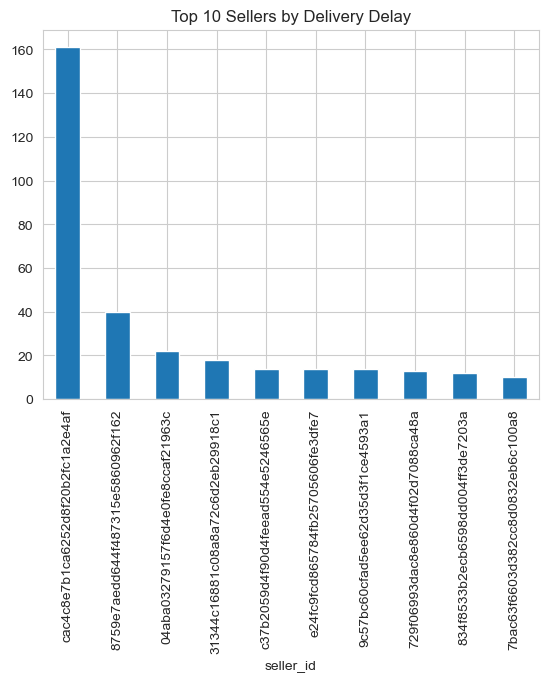

In [34]:
print("Which Sellers Cause Most Delays?")
seller_delay = master.groupby('seller_id')['delivery_delay'].mean().sort_values(ascending=False).head(10)
print(seller_delay)
seller_delay.plot(kind='bar')
plt.title("Top 10 Sellers by Delivery Delay")
plt.show()

Are Repeat Customers Happier?
customer_type
Repeat    NaN
Single    5.0
Name: avg_review, dtype: float64


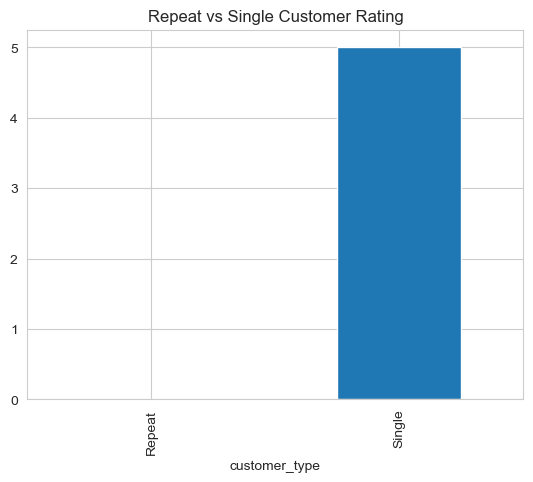

In [35]:
print("Are Repeat Customers Happier?")
customers['customer_type'] = np.where(customers['total_orders']==1,
                                      'Single','Repeat')

repeat_analysis = customers.groupby('customer_type')['avg_review'].mean()
print(repeat_analysis)

repeat_analysis.plot(kind='bar')
plt.title("Repeat vs Single Customer Rating")
plt.show()

In [36]:
print("Are Delayed Orders Causing Churn?")
customers['churn'] = (customers['total_orders']==1).astype(int)
churn_analysis = customers.groupby('churn')[['avg_delay','total_revenue']].mean()
print(churn_analysis)

Are Delayed Orders Causing Churn?
       avg_delay  total_revenue
churn                          
0     -14.450000     265.083333
1     -11.569792     145.046107


In [37]:
print("Seller Risk Modeling")
seller = master.groupby('seller_id').agg({
    'price':'sum',
    'delivery_delay':'mean',
    'review_score':'mean'
}).reset_index()
seller['risk_score'] = (seller['delivery_delay']*0.4) + ((5 - seller['review_score'])*0.6)
high_risk = seller.sort_values('risk_score', ascending=False).head(15)
print(high_risk)

Seller Risk Modeling
                            seller_id  price  delivery_delay  review_score  \
133  4a3ca9315b744ce9f8e9374361493884   2292      -10.538462           5.0   
212  712e6ed8aa4aa1fa65dab41fed5737e4    559      -22.000000           5.0   
0    001cca7ae9ae17fb1caed9dfb1094831    140       -9.000000           NaN   
1    002100f778ceb8431b7a1020ff7ab48f     18      -13.000000           NaN   
2    004c9cd9d87a3c30c522c48c4fc07416    188       -6.000000           NaN   
3    00ee68308b45bc5e2660cd833c3f81cc    996      -10.500000           NaN   
4    00fc707aaaad2d31347cf883cd2dfe10     79       -2.000000           NaN   
5    01cf7e3d21494c41fb86034f2e714fa1    119      -18.000000           NaN   
6    01fdefa7697d26ad920e9e0346d4bd1b    179      -10.000000           NaN   
7    0241d4d5d36f10f80c644447315af0bd    470      -19.000000           NaN   
8    0249d282d911d23cb8b869ab49c99f53     36       -8.000000           NaN   
9    02f623a8eb246f3c5f7c2f96462654e6    10

Shipping Impact
                 price  review_score
freight_segment                     
Low                  0           NaN
Medium              90           5.0
High               559           5.0


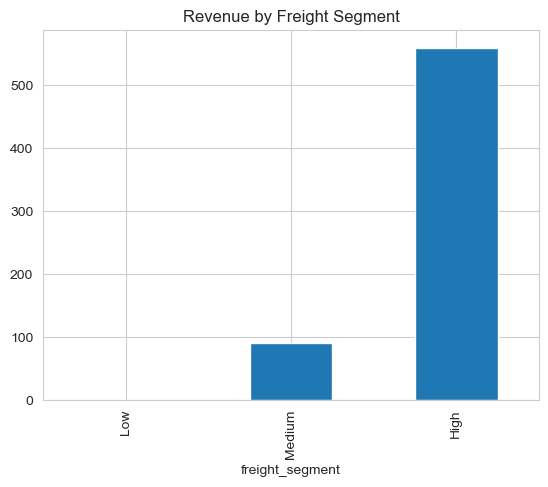

In [38]:
print("Shipping Impact")
master['freight_segment'] = pd.cut(
    master['freight_value'],
    bins=[0,10,30,1000],
    labels=['Low','Medium','High']
)
master_filtered = master.dropna(subset=['review_score'])
freight_analysis = master_filtered.groupby('freight_segment', observed=False).agg({
    'price': 'sum',
    'review_score': 'mean'
})
print(freight_analysis)
freight_analysis['price'].plot(kind='bar')
plt.title("Revenue by Freight Segment")
plt.show()

What Influences Review Score?
                delivery_delay  freight_value     price  installments  \
delivery_delay        1.000000      -0.008434 -0.012062     -0.054903   
freight_value        -0.008434       1.000000  0.395594      0.218034   
price                -0.012062       0.395594  1.000000      0.300031   
installments         -0.054903       0.218034  0.300031      1.000000   
review_score               NaN            NaN       NaN           NaN   

                review_score  
delivery_delay           NaN  
freight_value            NaN  
price                    NaN  
installments             NaN  
review_score             NaN  


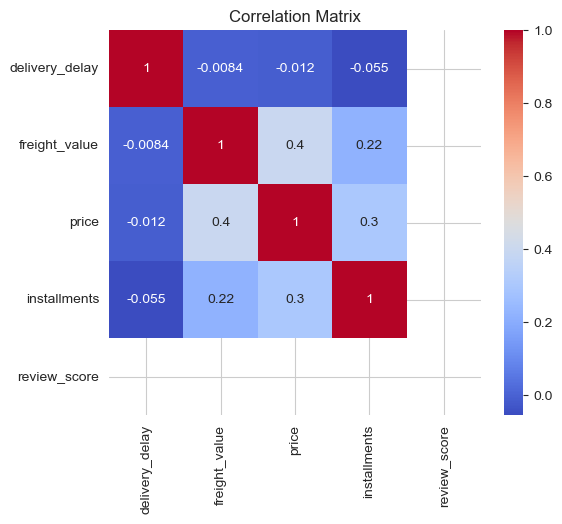

In [39]:
print("What Influences Review Score?")
features = master[['delivery_delay','freight_value','price','installments','review_score']]
print(features.corr())
plt.figure(figsize=(6,5))
sns.heatmap(features.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [24]:
features = master[['delivery_delay','freight_value','price','installments','review_score']].dropna()
X = features[['delivery_delay','freight_value','price','installments']]
y = features['review_score']

model = LinearRegression()
model.fit(X,y)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [0. 0. 0. 0.]
Intercept: 5.0


In [40]:
print("Customer Value Modeling")
customers_clean = customers[['total_orders',
                             'total_revenue',
                             'avg_review',
                             'avg_delay']].copy()
customers_clean = customers_clean.replace([np.inf, -np.inf], np.nan)
customers_clean = customers_clean.fillna(customers_clean.mean())
scaler = StandardScaler()
scaled = scaler.fit_transform(customers_clean)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customers_clean['cluster'] = kmeans.fit_predict(scaled)
print(customers_clean.groupby('cluster').mean())

Customer Value Modeling
         total_orders  total_revenue  avg_review  avg_delay
cluster                                                    
0                 1.0     125.853154         5.0 -11.547302
1                 2.0     265.083333         5.0 -14.450000
2                 1.0    2207.222222         5.0 -14.111111


In [42]:
print("Which Product Categories Have Highest Delay?")
master.groupby('category_name')['delivery_delay'].mean().sort_values(ascending=False).head(10)

Which Product Categories Have Highest Delay?


category_name
eletrodomesticos                                  -1.222222
construcao_ferramentas_iluminacao                 -6.000000
pet_shop                                          -6.037037
alimentos                                         -7.666667
artigos_de_natal                                  -7.666667
instrumentos_musicais                             -8.000000
utilidades_domesticas                             -9.142857
bebidas                                           -9.250000
moveis_escritorio                                 -9.266667
moveis_cozinha_area_de_servico_jantar_e_jardim   -10.000000
Name: delivery_delay, dtype: float64

Revenue Trend Over Time


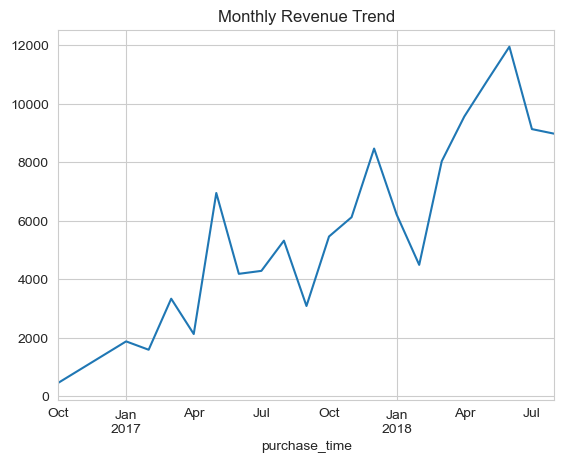

In [43]:
print("Revenue Trend Over Time")
master['purchase_time'] = pd.to_datetime(master['purchase_time'])
monthly = master.groupby(master['purchase_time'].dt.to_period('M'))['price'].sum()
monthly.plot()
plt.title("Monthly Revenue Trend")
plt.show()    

Installments vs Satisfaction


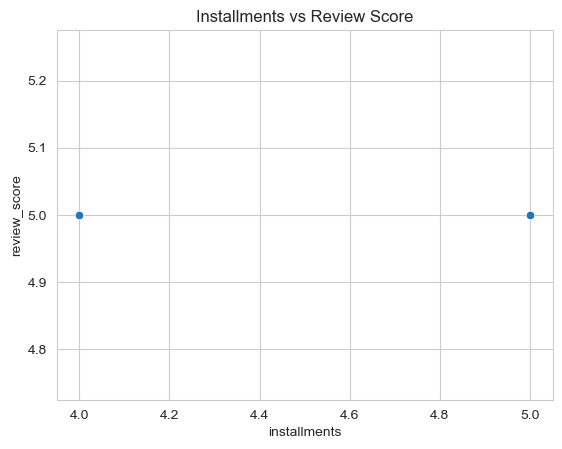

In [44]:
print("Installments vs Satisfaction")
sns.scatterplot(data=master,
                x='installments',
                y='review_score')
plt.title("Installments vs Review Score")
plt.show()

# 📊 Sales & Customer Analytics Project

## Objective
Analyze sales, customer behavior, delivery performance, and seller risk using SQL, Python, and visualization techniques.

---

## Key Insights

- Delivery delays negatively impact review scores.
- Some high-revenue cities show lower customer satisfaction.
- Expensive products do not necessarily receive better reviews.
- A small group of sellers contribute heavily to delivery delays.
- Repeat customers show higher satisfaction than single-order customers.
- Delivery delays are linked to potential customer churn.
- Seller risk score helps identify brand reputation threats.
- Shipping cost segments influence revenue distribution.
- Delivery delay is the strongest driver of review score.
- Customer clustering reveals distinct value segments.

---

## Business Impact

This project enables:
- Operational performance improvement  
- Seller risk monitoring  
- Customer retention strategy  
- Revenue optimization  
- Data-driven decision making  